<a href="https://colab.research.google.com/github/Shikaaaaaaaaa/Ahmedfathy.com/blob/main/Student_Performance_Dataset3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1st we have to import our libraries


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

lets Do Some EDA For our dataset


In [6]:
df = pd.read_csv('/content/student_data.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [8]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [9]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


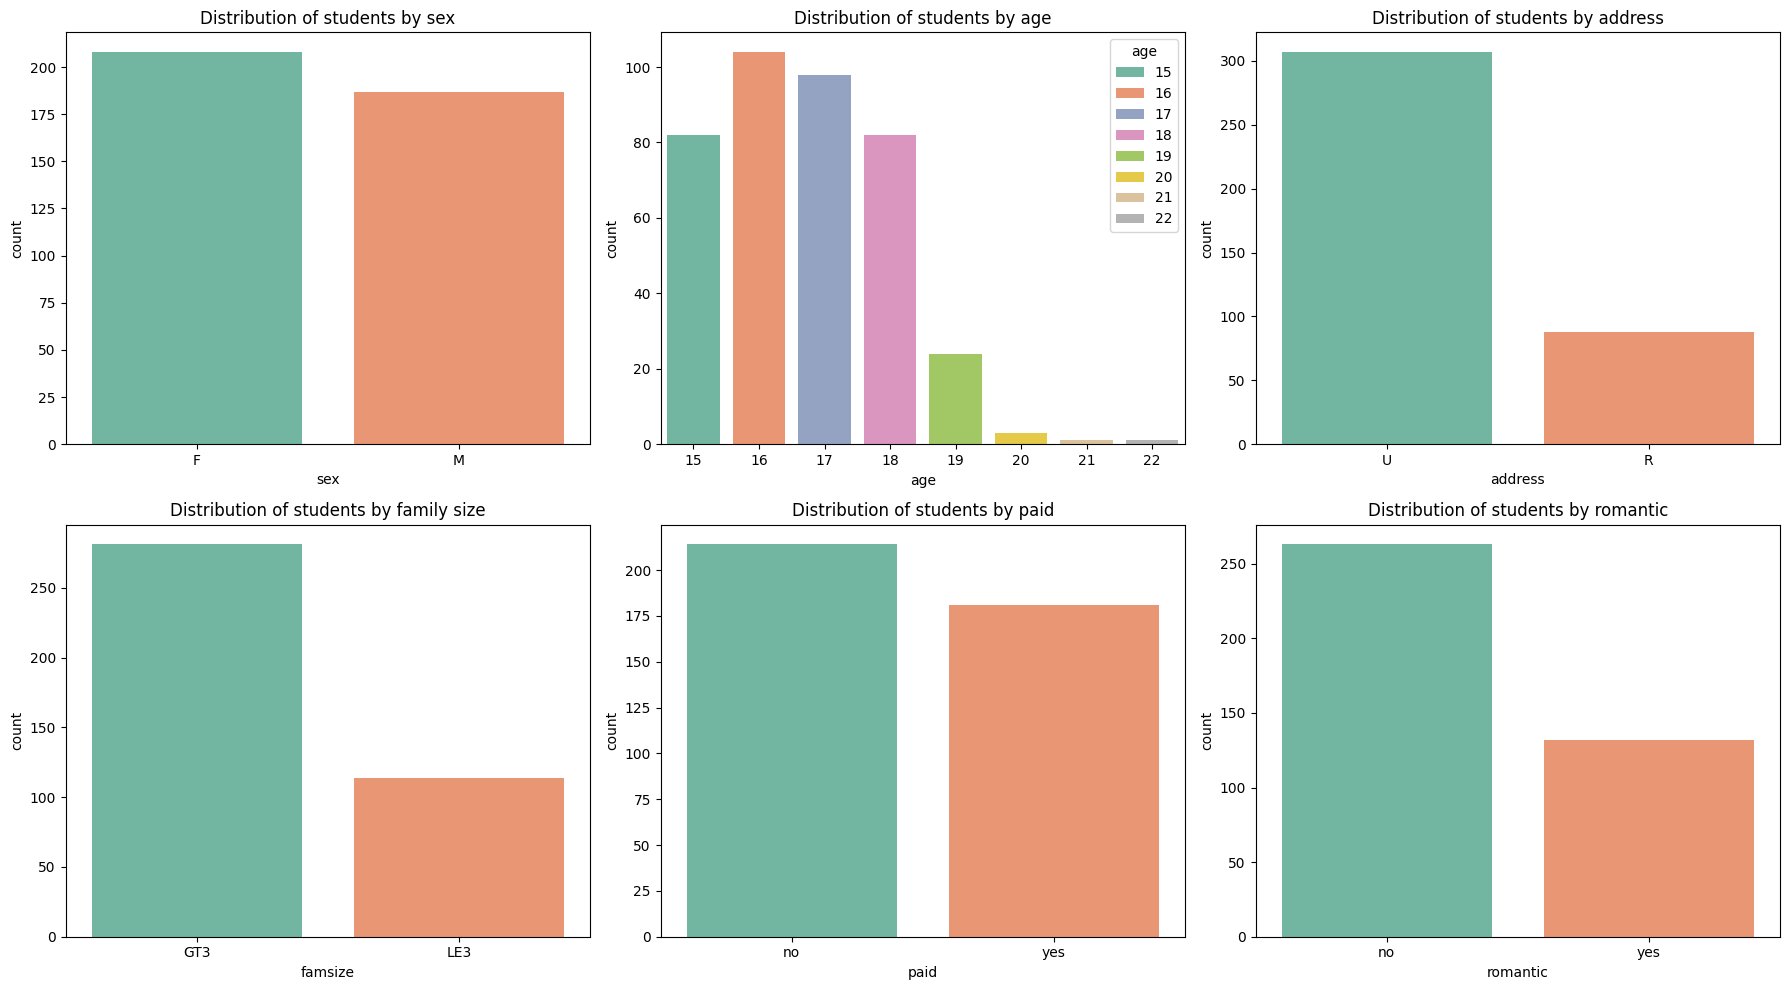

In [11]:
columns = ['sex','age','address','famsize','paid','romantic']
titles = [
    'Distribution of students by sex',
    'Distribution of students by age',
    'Distribution of students by address',
    'Distribution of students by family size',
    'Distribution of students by paid',
    'Distribution of students by romantic'
]
plt.figure(figsize=(18, 10))

for i, column in enumerate(columns):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=column, data=df, hue=column, palette='Set2')
    plt.title(titles[i])
plt.tight_layout()


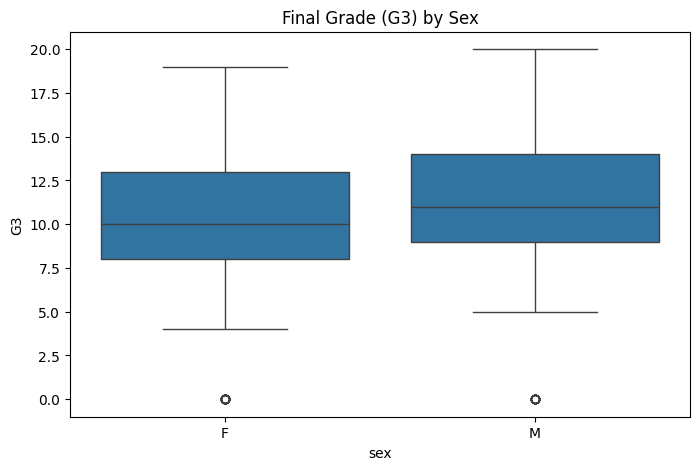

In [12]:
# 1. Let's look at how 'Sex' affects 'G3' using a simple boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='sex', y='G3', data=df)
plt.title('Final Grade (G3) by Sex')
plt.show()

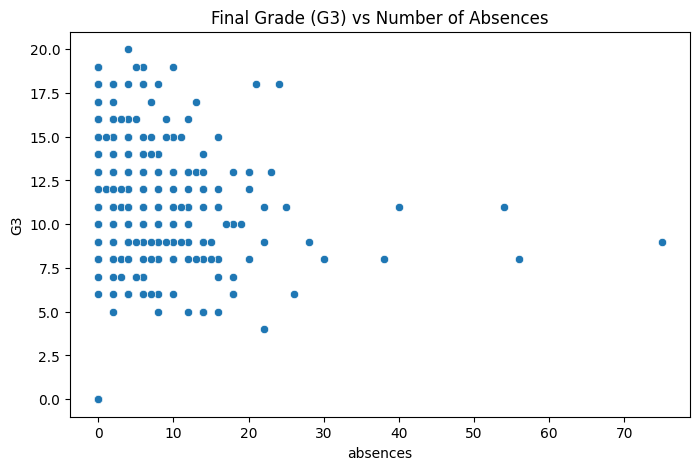

In [13]:
# 2. Now let's see if 'Absences' has a relationship with 'G3' using a scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='absences', y='G3', data=df)
plt.title('Final Grade (G3) vs Number of Absences')
plt.show()

Here the step for Cleaning and setup our data

In [14]:
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:                                                               # we used here 2 methods label ecoder and we used onehot encoder but inside pandas to make all our features ready for correlation
  if df_encoded[col].dtype == 'object':
    df_encoded[col] = le.fit_transform(df_encoded[col])
print(df_encoded)
df_encoded = pd.get_dummies(df_encoded, columns=['Mjob', 'Fjob', 'reason', 'guardian'])

     school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0         0    0   18        1        0        0     4     4     0     4  ...   
1         0    0   17        1        0        1     1     1     0     2  ...   
2         0    0   15        1        1        1     1     1     0     2  ...   
3         0    0   15        1        0        1     4     2     1     3  ...   
4         0    0   16        1        0        1     3     3     2     2  ...   
..      ...  ...  ...      ...      ...      ...   ...   ...   ...   ...  ...   
390       1    1   20        1        1        0     2     2     3     3  ...   
391       1    1   17        1        1        1     3     1     3     3  ...   
392       1    1   21        0        0        1     1     1     2     2  ...   
393       1    1   18        0        1        1     3     2     3     2  ...   
394       1    1   19        1        1        1     1     1     2     0  ...   

     famrel  freetime  goou

In [15]:
df_encoded=df_encoded.astype(int)                 # we change every column on the data to be int

In [16]:
df_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_2,Fjob_3,Fjob_4,reason_0,reason_1,reason_2,reason_3,guardian_0,guardian_1,guardian_2
0,0,0,18,1,0,0,4,4,2,2,...,0,0,1,1,0,0,0,0,1,0
1,0,0,17,1,0,1,1,1,1,2,...,1,0,0,1,0,0,0,1,0,0
2,0,0,15,1,1,1,1,1,1,2,...,1,0,0,0,0,1,0,0,1,0
3,0,0,15,1,0,1,4,2,1,3,...,0,1,0,0,1,0,0,0,1,0
4,0,0,16,1,0,1,3,3,1,2,...,1,0,0,0,1,0,0,1,0,0


In [17]:
df_encoded.info()              # here we checked everyone they r all integers now

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 46 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    int64
 1   sex         395 non-null    int64
 2   age         395 non-null    int64
 3   address     395 non-null    int64
 4   famsize     395 non-null    int64
 5   Pstatus     395 non-null    int64
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   traveltime  395 non-null    int64
 9   studytime   395 non-null    int64
 10  failures    395 non-null    int64
 11  schoolsup   395 non-null    int64
 12  famsup      395 non-null    int64
 13  paid        395 non-null    int64
 14  activities  395 non-null    int64
 15  nursery     395 non-null    int64
 16  higher      395 non-null    int64
 17  internet    395 non-null    int64
 18  romantic    395 non-null    int64
 19  famrel      395 non-null    int64
 20  freetime    395 non-null    int6

In [18]:
corr_g3 = df_encoded.corr()['G3'].sort_values(ascending = False)                  # Here we start to see our correlation with our Target G3
print(corr_g3)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
higher        0.182465
Fedu          0.152457
Mjob_1        0.116158
address       0.105756
sex           0.103456
paid          0.101996
internet      0.098483
studytime     0.097820
reason_3      0.095692
Fjob_4        0.095374
famsize       0.081407
Mjob_3        0.078429
Mjob_4        0.057712
Fjob_1        0.057111
reason_2      0.052008
nursery       0.051568
famrel        0.051363
absences      0.034247
guardian_0    0.032493
guardian_1    0.022338
activities    0.016100
freetime      0.011307
Fjob_0       -0.013385
Fjob_3       -0.016108
reason_1     -0.021359
famsup       -0.039157
school       -0.045017
Walc         -0.051939
Fjob_2       -0.053483
Dalc         -0.054660
Pstatus      -0.058009
health       -0.061335
schoolsup    -0.082788
guardian_2   -0.087774
Mjob_2       -0.096477
reason_0     -0.098950
Mjob_0       -0.115634
traveltime   -0.117142
romantic     -0.129970
goout      

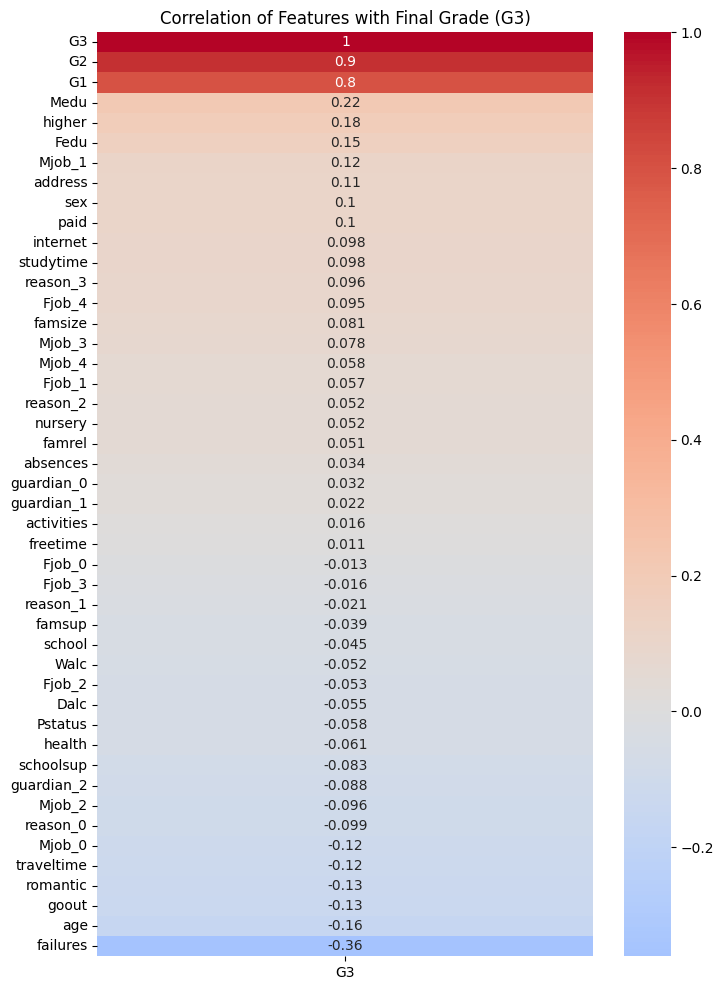

In [19]:
corr_g3 = df_encoded.corr()[['G3']].sort_values(by='G3', ascending=False)

plt.figure(figsize=(8, 12))
sns.heatmap(corr_g3, annot=True, cmap='coolwarm', center=0)                                     # this heatmap let us see correlation better
plt.title('Correlation of Features with Final Grade (G3)')
plt.show()

In [33]:
# 1. Create a new feature 'total_alc' by combining weekday and weekend drinking
df_encoded['total_alc'] = df_encoded['Dalc'] + df_encoded['Walc']                                 # here i decide that i can merge to features together


# 2. Use all columns except the target G3
# We drop 'G3' from df_encoded because it contains our engineered features too
X = df_encoded.drop(['G1', 'G2', 'G3'], axis=1)
y = df_encoded['G3']

print(f"All features included! Total features: {X.shape[1]}")
display(X.head())

All features included! Total features: 44


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_3,Fjob_4,reason_0,reason_1,reason_2,reason_3,guardian_0,guardian_1,guardian_2,total_alc
0,0,0,18,1,0,0,4,4,2,2,...,0,1,1,0,0,0,0,1,0,2
1,0,0,17,1,0,1,1,1,1,2,...,0,0,1,0,0,0,1,0,0,2
2,0,0,15,1,1,1,1,1,1,2,...,0,0,0,0,1,0,0,1,0,5
3,0,0,15,1,0,1,4,2,1,3,...,1,0,0,1,0,0,0,1,0,2
4,0,0,16,1,0,1,3,3,1,2,...,0,0,0,1,0,0,1,0,0,3


In [34]:
# Re-splitting with the full feature set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

after splitting our data we will try to use 2 models


In [35]:

st_model = LinearRegression()
st_model.fit(X_train,y_train)

LinearRegression()

In [36]:
y_pred = st_model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(r2)
print(mse)

-0.284992834775069
17.568226024678346


In [58]:
# Re-training the Random Forest
st_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=1
)
st_model.fit(X_train, y_train)
importance = st_model.feature_importances_

In [59]:
feature_names = X.columns
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

In [60]:
feat_imp.head()

,Feature,Importance
25,absences,0.186939
10,failures,0.138044
21,goout,0.045673
2,age,0.040705
20,freetime,0.037530


In [61]:
y_pred = st_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"New R2 Score (All Features): {r2:.4f}")
print(f"New MSE: {mse:.4f}")

New R2 Score (All Features): 0.3800
New MSE: 8.4769


Random Forest looks better for our dataset

In [62]:
print("Train R2:", st_model.score(X_train, y_train))
print("Test R2:", st_model.score(X_test, y_test))                # Here We find out that we have overfit

Train R2: 0.8245312023127711
Test R2: 0.3799770450813488


we have to finetune RandomForest

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=1
)

rf.fit(X_train, y_train)

print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

Train R2: 0.5317332665258643
Test R2: 0.40825336305503246
